# Sequence Models — RNN, LSTM & GRU
## Hands-on Lab: Next-Step Sequence Prediction

### Learning Objectives
By the end of this notebook, you should be able to:

- Prepare sequential data using **sliding windows**.
- Explain the Keras input shape: **samples × timesteps × features**.
- Build and train `SimpleRNN`, `LSTM`, and `GRU`.
- Compare model performance and parameter count.
- Understand when `return_sequences=True` is needed.
- Complete coding and reasoning tasks independently.

### Pipeline
**Raw Sequence → Sliding Windows → 3D Input → Sequence Model → Prediction → Evaluation**


## 1. Import Libraries

In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Create Sequential Data

We will use a **sine wave** as a simple sequence.

Our task:

> Given the previous `N` values, predict the next value.


In [2]:
n_points = 1000
x_axis = np.linspace(0, 40, n_points)
series = np.sin(x_axis)

print("Series shape:", series.shape)
print("First 10 values:", series[:10])


Series shape: (1000,)
First 10 values: [0.         0.04002934 0.07999452 0.11983146 0.15947632 0.19886554
 0.23793597 0.276625   0.3148706  0.35261147]


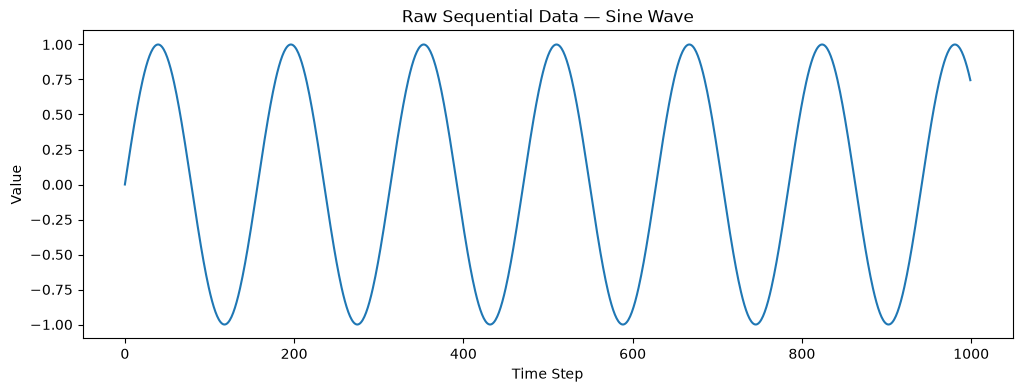

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(series)
plt.title("Raw Sequential Data — Sine Wave")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()


## 3. Chronological Train/Test Split

Sequence order matters, so we keep the original order.

- First 80% → training
- Last 20% → testing


In [4]:
split_index = int(len(series) * 0.80)

train_series = series[:split_index]
test_series = series[split_index:]

print("Training points:", len(train_series))
print("Test points:", len(test_series))


Training points: 800
Test points: 200


## 4. Sliding Windows

If `seq_length = 10`:

`[x1 ... x10] → x11`

then:

`[x2 ... x11] → x12`

This converts the raw sequence into supervised learning samples.


In [5]:
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    X = np.array(X)
    y = np.array(y)

    # Keras sequence layers expect 3D input:
    # samples × timesteps × features
    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y


In [6]:
SEQ_LENGTH = 10

X_train, y_train = create_sequences(train_series, SEQ_LENGTH)
X_test, y_test = create_sequences(test_series, SEQ_LENGTH)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (790, 10, 1)
y_train: (790,)
X_test : (190, 10, 1)
y_test : (190,)


### Understanding the Shape

For example:

`X_train.shape = (790, 10, 1)`

means:

- `790` samples
- `10` timesteps per sample
- `1` feature at each timestep


In [7]:
sample_id = 0

print("Input sequence:")
print(X_train[sample_id].flatten())

print("\nTarget:")
print(y_train[sample_id])


Input sequence:
[0.         0.04002934 0.07999452 0.11983146 0.15947632 0.19886554
 0.23793597 0.276625   0.3148706  0.35261147]

Target:
0.38978710427372076


## 5. Helper Function for Training

We will train each model under similar conditions so the comparison is fair.


In [8]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=50):
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    training_time = time.time() - start

    predictions = model.predict(X_test, verbose=0).flatten()

    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)

    return history, predictions, mse, mae, training_time


# Part A — Simple RNN

A basic RNN processes the sequence step by step and carries a **hidden state** forward.


In [9]:
rnn_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    SimpleRNN(32),
    Dense(1)
])

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
rnn_history, rnn_pred, rnn_mse, rnn_mae, rnn_time = train_and_evaluate(
    rnn_model,
    X_train, y_train,
    X_test, y_test
)

print("RNN MSE:", round(rnn_mse, 6))
print("RNN MAE:", round(rnn_mae, 6))
print("Training time:", round(rnn_time, 2), "seconds")


RNN MSE: 2.6e-05
RNN MAE: 0.004557
Training time: 4.4 seconds


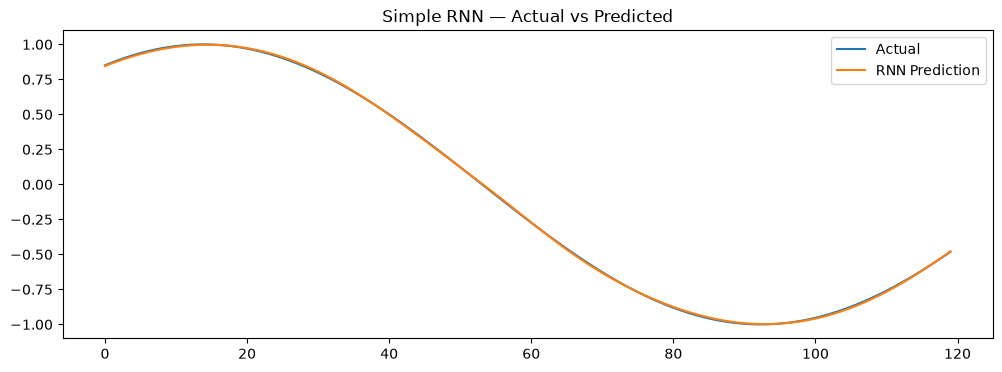

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(y_test[:120], label="Actual")
plt.plot(rnn_pred[:120], label="RNN Prediction")
plt.title("Simple RNN — Actual vs Predicted")
plt.legend()
plt.show()


# Part B — LSTM

LSTM improves memory control using:

- Forget Gate
- Input Gate
- Output Gate
- Cell State


In [12]:
lstm_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(32),
    Dense(1)
])

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
lstm_history, lstm_pred, lstm_mse, lstm_mae, lstm_time = train_and_evaluate(
    lstm_model,
    X_train, y_train,
    X_test, y_test
)

print("LSTM MSE:", round(lstm_mse, 6))
print("LSTM MAE:", round(lstm_mae, 6))
print("Training time:", round(lstm_time, 2), "seconds")


LSTM MSE: 2.8e-05
LSTM MAE: 0.004218
Training time: 3.76 seconds


# Part C — GRU

GRU is a simpler gated recurrent model with fewer gates and usually fewer parameters than LSTM.


In [14]:
gru_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    GRU(32),
    Dense(1)
])

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
gru_history, gru_pred, gru_mse, gru_mae, gru_time = train_and_evaluate(
    gru_model,
    X_train, y_train,
    X_test, y_test
)

print("GRU MSE:", round(gru_mse, 6))
print("GRU MAE:", round(gru_mae, 6))
print("Training time:", round(gru_time, 2), "seconds")


GRU MSE: 1.5e-05
GRU MAE: 0.003291
Training time: 4.92 seconds


## 6. Compare the Three Models

The same dataset and sequence length are used for all models.


In [16]:
comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "MSE": [rnn_mse, lstm_mse, gru_mse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],
    "Training Time (sec)": [
        rnn_time,
        lstm_time,
        gru_time
    ]
})

comparison


,Model,MSE,MAE,Parameters,Training Time (sec)
0,Simple RNN,0.000026,0.004557,1121,4.400069
1,LSTM,0.000028,0.004218,4385,3.755359
2,GRU,0.000015,0.003291,3393,4.918895


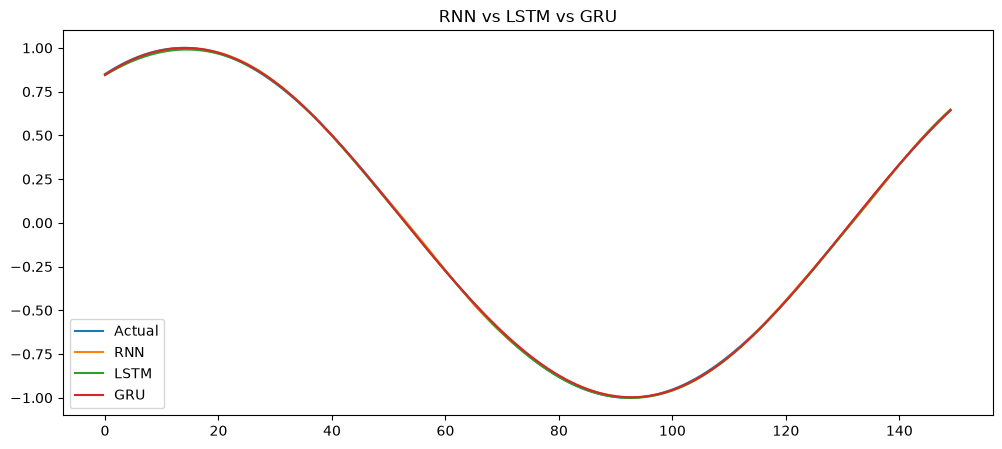

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(y_test[:150], label="Actual")
plt.plot(rnn_pred[:150], label="RNN")
plt.plot(lstm_pred[:150], label="LSTM")
plt.plot(gru_pred[:150], label="GRU")
plt.title("RNN vs LSTM vs GRU")
plt.legend()
plt.show()


## 7. Stacked LSTM and `return_sequences=True`

When one LSTM layer is followed by another LSTM layer, the first layer must return a **sequence**, not only one final vector.

That is why we use:

```python
LSTM(50, return_sequences=True)
```


In [18]:
stacked_lstm = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(50, return_sequences=True),
    LSTM(30),
    Dense(1)
])

stacked_lstm.compile(optimizer="adam", loss="mse")
stacked_lstm.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Predict the Next Value

Use the last sequence to predict the next point.


In [19]:
last_sequence = series[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)

print("RNN :", float(rnn_model.predict(last_sequence, verbose=0)[0, 0]))
print("LSTM:", float(lstm_model.predict(last_sequence, verbose=0)[0, 0]))
print("GRU :", float(gru_model.predict(last_sequence, verbose=0)[0, 0]))


RNN : 0.7233937978744507
LSTM: 0.721327543258667


GRU : 0.7224808931350708


# Student Tasks

Complete the following tasks independently.


## Task 1 — Understand the Input Shape

Suppose:

```python
X.shape = (500, 20, 3)
```

Answer:

1. How many samples are there?
   - 500
2. How many timesteps are in each sample?
   - 20
3. How many features exist at each timestep?
   - 3
4. What does the second dimension represent?
   - the timesteps, the position inside one window


## Task 2 — Change the Sequence Length

Repeat the LSTM experiment with:

- `seq_length = 5`
- `seq_length = 20`

For each experiment:

1. Create the sliding windows.
2. Build an LSTM with 32 units.
3. Train it.
4. Calculate test MSE.
5. Compare the results.

### Reflection
Does a longer sequence always improve performance? Why?

- no
- here it helped: MSE went 0.001080 (5) to 0.000028 (10) to 0.000010 (20), because 5 points of a sine do not pin down where you are on the curve
- but every extra timestep costs training samples, compute, and a longer path for the gradient
- once the window covers the pattern, more history adds noise, not information


In [20]:
# TODO — Task 2

task2_results = []

experiment_seq_length = 5

X_train_5, y_train_5 = create_sequences(train_series, experiment_seq_length)
X_test_5, y_test_5 = create_sequences(test_series, experiment_seq_length)

lstm_5 = Sequential([
    keras.Input(shape=(experiment_seq_length, 1)),
    LSTM(32),
    Dense(1)
])

_, pred_5, mse_5, mae_5, time_5 = train_and_evaluate(
    lstm_5, X_train_5, y_train_5, X_test_5, y_test_5
)

task2_results.append({
    "Sequence Length": experiment_seq_length,
    "Training Samples": X_train_5.shape[0],
    "Test MSE": mse_5,
    "Training Time (sec)": time_5
})

print("X_train_5:", X_train_5.shape)
print("Test MSE:", round(mse_5, 6))


X_train_5: (795, 5, 1)
Test MSE: 0.00108


In [21]:
experiment_seq_length = 20

X_train_20, y_train_20 = create_sequences(train_series, experiment_seq_length)
X_test_20, y_test_20 = create_sequences(test_series, experiment_seq_length)

lstm_20 = Sequential([
    keras.Input(shape=(experiment_seq_length, 1)),
    LSTM(32),
    Dense(1)
])

_, pred_20, mse_20, mae_20, time_20 = train_and_evaluate(
    lstm_20, X_train_20, y_train_20, X_test_20, y_test_20
)

task2_results.append({
    "Sequence Length": experiment_seq_length,
    "Training Samples": X_train_20.shape[0],
    "Test MSE": mse_20,
    "Training Time (sec)": time_20
})

print("X_train_20:", X_train_20.shape)
print("Test MSE:", round(mse_20, 6))


X_train_20: (780, 20, 1)
Test MSE: 1e-05


In [22]:
task2_table = pd.DataFrame(task2_results + [{
    "Sequence Length": SEQ_LENGTH,
    "Training Samples": X_train.shape[0],
    "Test MSE": lstm_mse,
    "Training Time (sec)": lstm_time
}]).sort_values("Sequence Length").reset_index(drop=True)

task2_table


,Sequence Length,Training Samples,Test MSE,Training Time (sec)
0,5,795,0.001080,4.301555
1,10,790,0.000028,3.755359
2,20,780,0.000010,5.385393


## Task 3 — Change the Number of Hidden Units

Train LSTM models with:

- 16 units
- 32 units
- 64 units

Create a comparison table containing:

- Hidden Units
- Number of Parameters
- Test MSE

### Question
Does increasing the number of units always improve the model?

- no
- here it did: 8.5e-05 (16) to 3.7e-06 (32) to 6.5e-07 (64), because a clean sine is easy to fit
- parameters grow far faster than the gain: 1,169 to 4,385 to 16,961
- on noisy or small data the extra capacity memorizes the training set instead of generalizing


In [23]:
# TODO — Task 3

units_to_test = [16, 32, 64]
task3_results = []

lstm_16 = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(16),
    Dense(1)
])

_, _, mse_16, mae_16, time_16 = train_and_evaluate(
    lstm_16, X_train, y_train, X_test, y_test
)

task3_results.append({
    "Hidden Units": 16,
    "Parameters": lstm_16.count_params(),
    "Test MSE": mse_16
})

print("16 units | parameters:", lstm_16.count_params(), "| Test MSE:", round(mse_16, 6))


16 units | parameters: 1169 | Test MSE: 8.5e-05


In [24]:
lstm_32 = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(32),
    Dense(1)
])

_, _, mse_32, mae_32, time_32 = train_and_evaluate(
    lstm_32, X_train, y_train, X_test, y_test
)

task3_results.append({
    "Hidden Units": 32,
    "Parameters": lstm_32.count_params(),
    "Test MSE": mse_32
})

print("32 units | parameters:", lstm_32.count_params(), "| Test MSE:", round(mse_32, 6))


32 units | parameters: 4385 | Test MSE: 4e-06


In [25]:
lstm_64 = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(64),
    Dense(1)
])

_, _, mse_64, mae_64, time_64 = train_and_evaluate(
    lstm_64, X_train, y_train, X_test, y_test
)

task3_results.append({
    "Hidden Units": 64,
    "Parameters": lstm_64.count_params(),
    "Test MSE": mse_64
})

print("64 units | parameters:", lstm_64.count_params(), "| Test MSE:", round(mse_64, 6))


64 units | parameters: 16961 | Test MSE: 1e-06


In [26]:
task3_table = pd.DataFrame(task3_results)

task3_table


,Hidden Units,Parameters,Test MSE
0,16,1169,8.476004e-05
1,32,4385,3.672037e-06
2,64,16961,6.514623e-07


## Task 4 — Build a Stacked LSTM

Build:

```text
LSTM(50)
LSTM(30)
Dense(1)
```

Make the architecture work correctly.

### Questions

1. Which LSTM layer needs `return_sequences=True`?
   - the first one, `LSTM(50)`
2. Why?
   - the second LSTM is a sequence layer, so it needs a value at every timestep, not one summary vector
3. What happens if the first LSTM returns only one final vector?
   - it outputs 2D `(batch, 50)`, the second LSTM expects 3D, and Keras raises a shape error


In [27]:
# TODO — Task 4

stacked_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(50, return_sequences=True),
    LSTM(30),
    Dense(1)
])

stacked_model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

## Task 5 — Compare RNN, LSTM, and GRU

Using the comparison table:

1. Which model has the fewest parameters?
   - simple RNN, 1,121 against GRU 3,393 and LSTM 4,385
2. Which model trained fastest?
   - changes every run; in this run LSTM at 3.76s, because early stopping decides how many epochs each model gets
3. Which model achieved the lowest MSE?
   - changes every run; in this run GRU at 0.000015
4. Why should we not assume that one model is always best?
   - all three land around 0.00002 on a clean sine, so the gap between them is smaller than the run-to-run noise
   - the ranking flips on a re-run or another machine, and the right choice depends on the data, not the architecture name


## Task 6 — Add Noise

Create a harder sequence:

```python
noisy_series = np.sin(x_axis) + np.random.normal(
    0, 0.15, size=len(x_axis)
)
```

Then:

1. Split the sequence chronologically.
2. Create sliding windows.
3. Train an LSTM.
4. Calculate test MSE.
5. Plot actual vs predicted values.

### Reflection
How does noise affect sequence learning?

- MSE jumps from 0.000028 to 0.027051, about 1000x worse
- most of that is unfixable: the noise variance is 0.15^2 = 0.0225, and nothing can predict random values
- scored against the clean sine instead, the same predictions give 0.007972, so the model still found the underlying wave
- noise raises the error floor, it does not stop the pattern being learned


In [28]:
# TODO — Task 6

noisy_series = np.sin(x_axis) + np.random.normal(
    0, 0.15, size=len(x_axis)
)

noisy_train = noisy_series[:split_index]
noisy_test = noisy_series[split_index:]

X_train_noisy, y_train_noisy = create_sequences(noisy_train, SEQ_LENGTH)
X_test_noisy, y_test_noisy = create_sequences(noisy_test, SEQ_LENGTH)

noisy_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(32),
    Dense(1)
])

_, noisy_pred, noisy_mse, noisy_mae, noisy_time = train_and_evaluate(
    noisy_model, X_train_noisy, y_train_noisy, X_test_noisy, y_test_noisy
)

print("Noisy test MSE:", round(noisy_mse, 6))
print("Clean test MSE:", round(lstm_mse, 6))
print("Noise variance floor:", round(0.15 ** 2, 6))

clean_target = series[split_index + SEQ_LENGTH:]
print("Same predictions scored against the clean sine:", round(mean_squared_error(clean_target, noisy_pred), 6))


Noisy test MSE: 0.027051
Clean test MSE: 2.8e-05
Noise variance floor: 0.0225
Same predictions scored against the clean sine: 0.007972


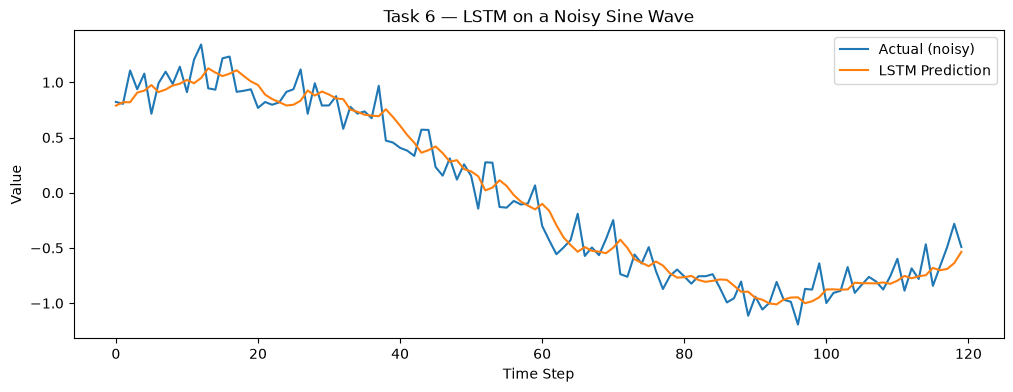

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_noisy[:120], label="Actual (noisy)")
plt.plot(noisy_pred[:120], label="LSTM Prediction")
plt.title("Task 6 — LSTM on a Noisy Sine Wave")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()


## Bonus Task — Multiple Features

Create two features:

```python
feature_1 = np.sin(x_axis)
feature_2 = np.cos(x_axis)
```

Use both features to predict the next sine value.

Your input shape should become:

**(samples, timesteps, 2)**

### Questions

1. Why is the final dimension now `2`?
   - each timestep now carries two values, sin and cos, instead of one
2. What must change in `input_shape`?
   - `(SEQ_LENGTH, 1)` becomes `(SEQ_LENGTH, 2)`
3. Does the whole model architecture need to change?
   - no, only the input weights widen: parameters go 4,385 to 4,513 and the layers stay the same


In [30]:
feature_1 = np.sin(x_axis)
feature_2 = np.cos(x_axis)
features = np.column_stack([feature_1, feature_2])


def create_multifeature_sequences(features, target, seq_length=10):
    X, y = [], []

    for i in range(len(features) - seq_length):
        X.append(features[i:i + seq_length])
        y.append(target[i + seq_length])

    return np.array(X), np.array(y)


X_train_multi, y_train_multi = create_multifeature_sequences(
    features[:split_index], feature_1[:split_index], SEQ_LENGTH
)
X_test_multi, y_test_multi = create_multifeature_sequences(
    features[split_index:], feature_1[split_index:], SEQ_LENGTH
)

multi_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 2)),
    LSTM(32),
    Dense(1)
])

_, multi_pred, multi_mse, multi_mae, multi_time = train_and_evaluate(
    multi_model, X_train_multi, y_train_multi, X_test_multi, y_test_multi
)

print("X_train_multi:", X_train_multi.shape)
print("Two-feature test MSE:", round(multi_mse, 6))
print("One-feature test MSE:", round(lstm_mse, 6))


X_train_multi: (790, 10, 2)
Two-feature test MSE: 1e-06
One-feature test MSE: 2.8e-05


# Self-Check Questions

1. Why does a Dense network not naturally remember previous timesteps?
   - it sees one flat vector and keeps no state between inputs, so order is lost
2. What is the role of the hidden state in an RNN?
   - it is a running summary of everything seen so far, passed from step to step
3. What is the main limitation of a basic RNN on long sequences?
   - gradients vanish over many steps, so early timesteps stop affecting learning
4. How does LSTM improve memory control?
   - gates decide what to forget, what to add, and what to output, keeping a path for information across many steps
5. What is the difference between cell state and hidden state?
   - cell state is the long-term memory line, hidden state is what the layer outputs at that step
6. Why is GRU considered simpler than LSTM?
   - two gates instead of three and no separate cell state, so fewer parameters
7. What does `return_sequences=True` do?
   - returns an output at every timestep (3D) instead of only the last one
8. Explain `(samples, timesteps, features)`.
   - how many windows, how long each window is, how many values per timestep
9. What is the purpose of a sliding window?
   - it turns one long series into supervised pairs of input window and next value
10. Why should chronological sequence data not be randomly shuffled before splitting?
    - it leaks future points into training and destroys the order the model is supposed to learn


## Key Takeaways

- Sequence models are designed for data where **order matters**.
- RNN carries information using a **hidden state**.
- LSTM improves long-term memory using **gates and cell state**.
- GRU is a simpler gated recurrent architecture.
- Keras sequence models expect **3D input**:
  **samples × timesteps × features**
- Sliding windows convert a raw sequence into supervised learning samples.
